프로젝트 2번의 A에 해당하는 코드입니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import cv2

image_paths = [
    '/content/drive/My Drive/Colab Notebooks/D1_16.png',
    '/content/drive/My Drive/Colab Notebooks/D2_16.png',
    '/content/drive/My Drive/Colab Notebooks/D3_16.png',
    '/content/drive/My Drive/Colab Notebooks/D4_16.png',
    '/content/drive/My Drive/Colab Notebooks/D5_16.png'
]

# MSE 계산 함수
def calculate_mse(original, restored):
    return np.mean((original - restored) ** 2)

Mounted at /content/drive


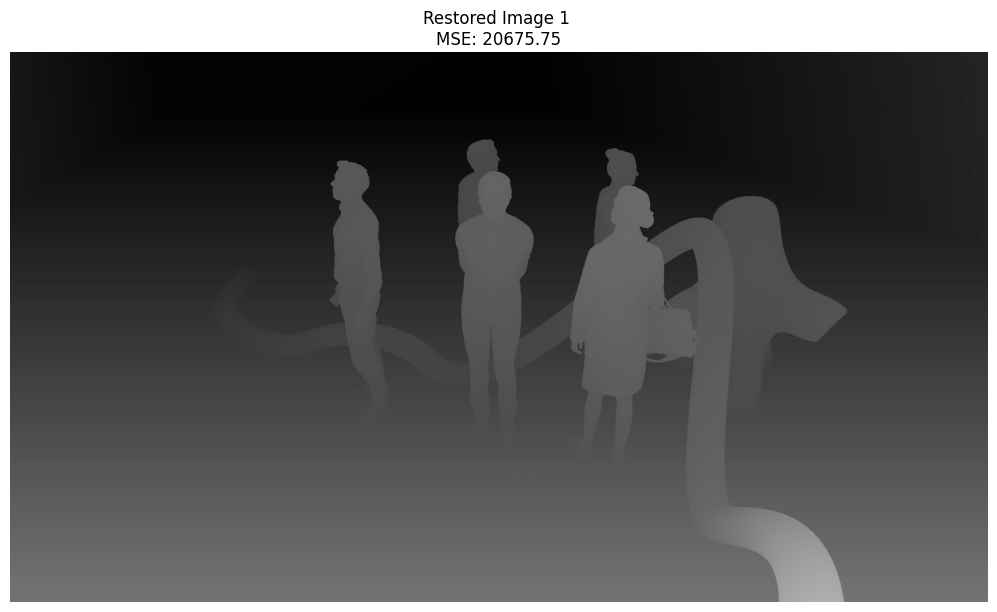

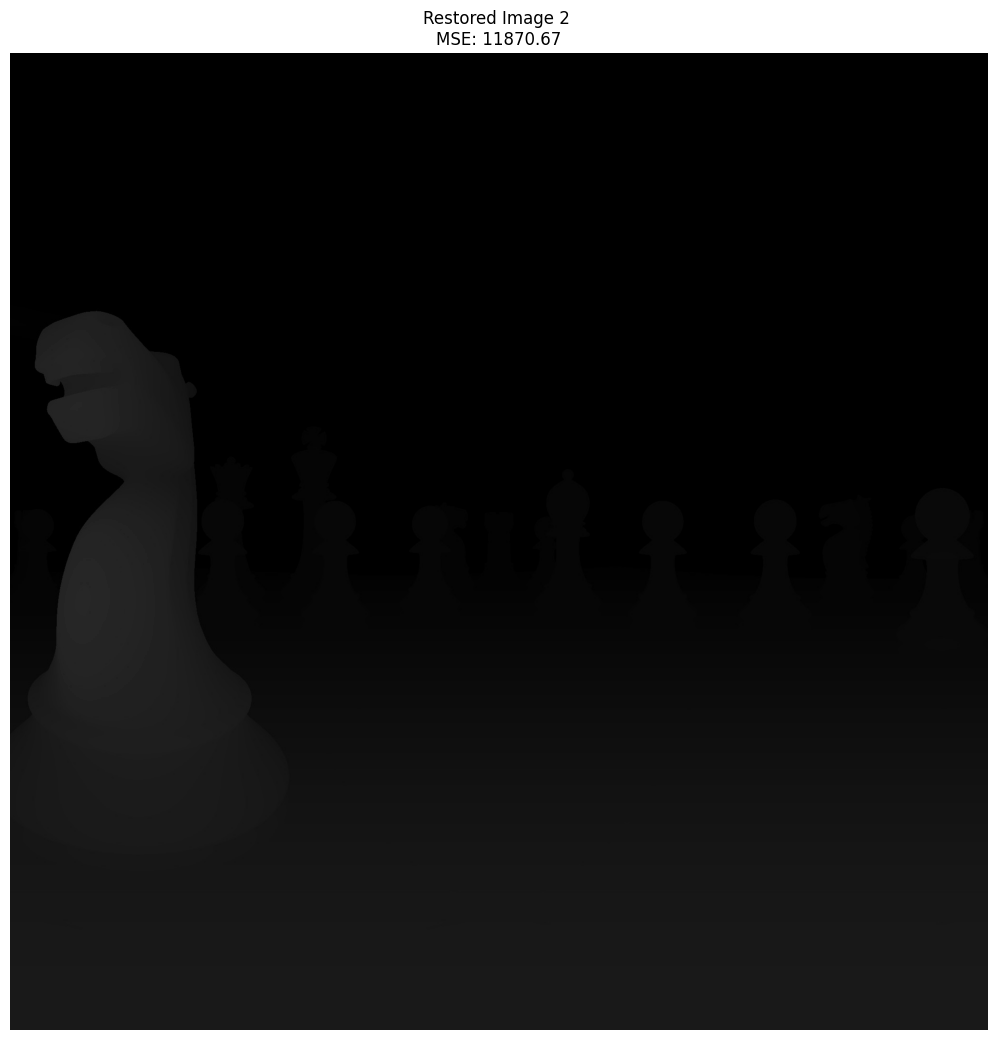

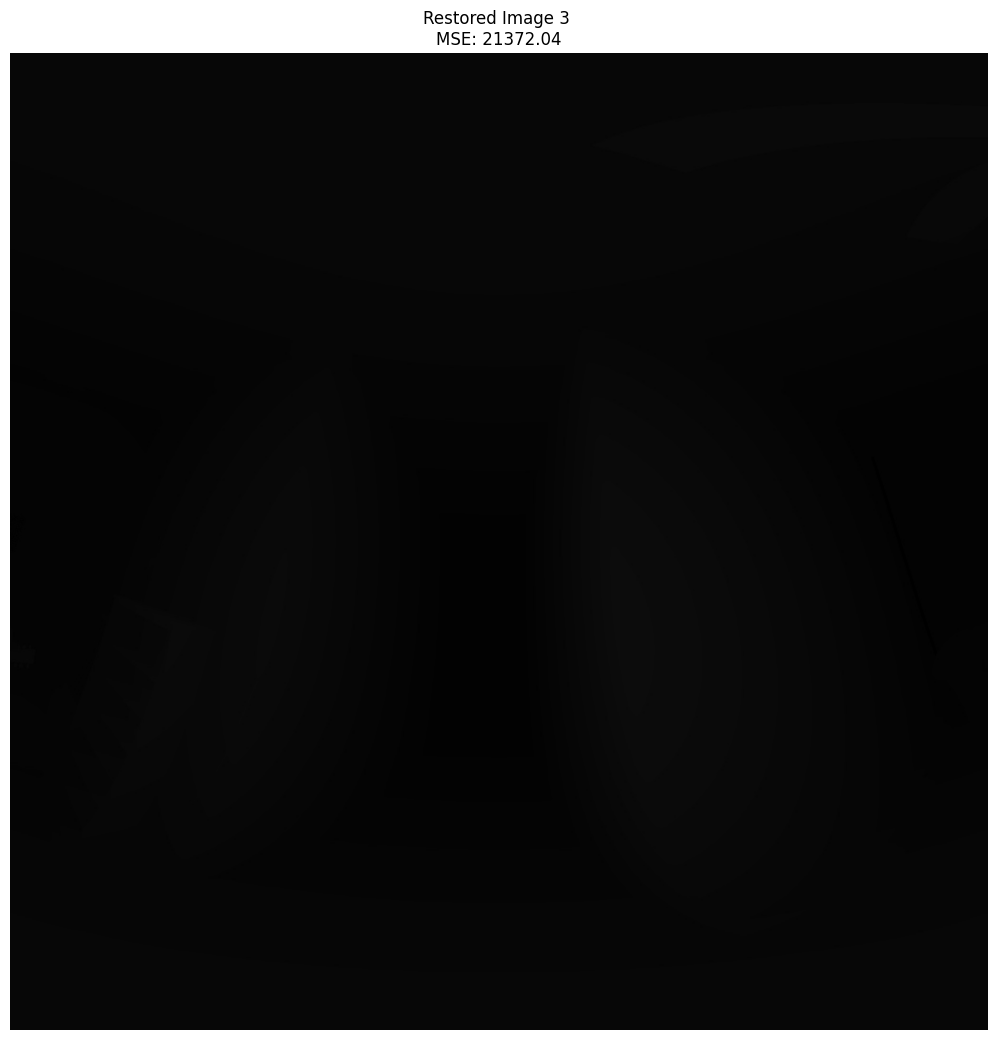

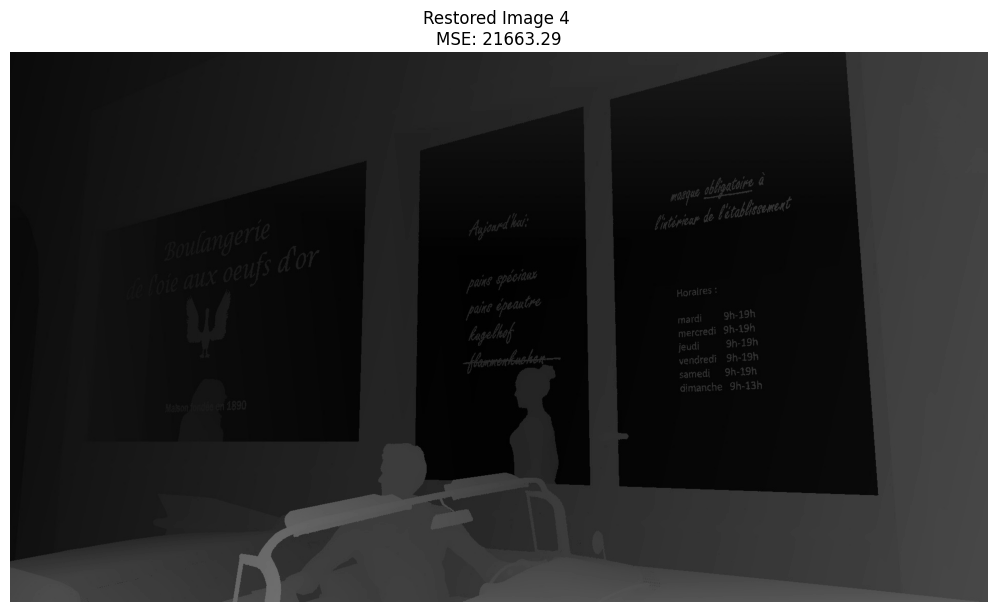

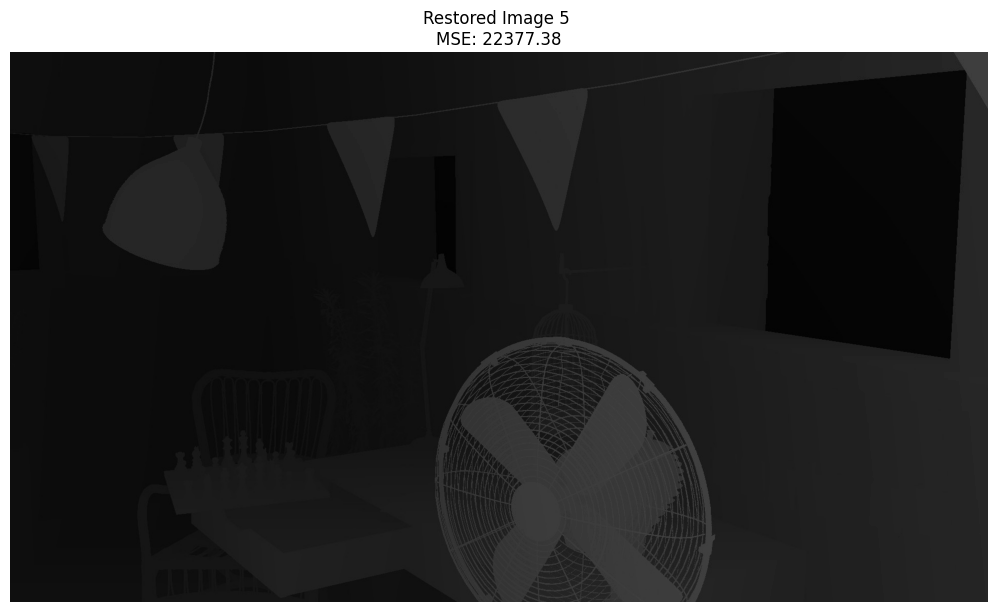

In [ ]:
#방법1 코드

def method_1(image_paths):
    for idx, image_path in enumerate(image_paths):

        depth_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        upper_8bit = (depth_16bit >> 8).astype(np.uint8)

        #Gaussian 노이즈 추가
        noise = np.random.normal(0, 10, upper_8bit.shape).astype(np.int16)                        # Gaussian 노이즈 표준편차 설정
        noisy_upper_8bit = np.clip(upper_8bit + noise, 0, 255).astype(np.uint8)  # 노이즈 추가 후 클리핑

        #JPEG 압축
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 90]                                        # QP 설정
        _, compressed_img = cv2.imencode('.jpg',upper_8bit , encode_param)                        # JPEG로 압축
        decoded_img = cv2.imdecode(compressed_img, cv2.IMREAD_UNCHANGED)                          # 다시 복원

        restored_16bit = (decoded_img.astype(np.uint16) << 8)                                     #가우시안 & JPEG 선택
        mse_value = calculate_mse(depth_16bit, restored_16bit)

        #이미지 시각화
        plt.figure(figsize=(20, 20))

        #복원된 16비트 이미지
        plt.subplot(1, 2, 1)
        plt.title(f'Restored Image {idx + 1} \nMSE: {mse_value:.2f}')
        plt.imshow(restored_16bit, cmap='gray', vmin=0, vmax=65535)
        plt.axis('off')

        plt.show()

method_1(image_paths)


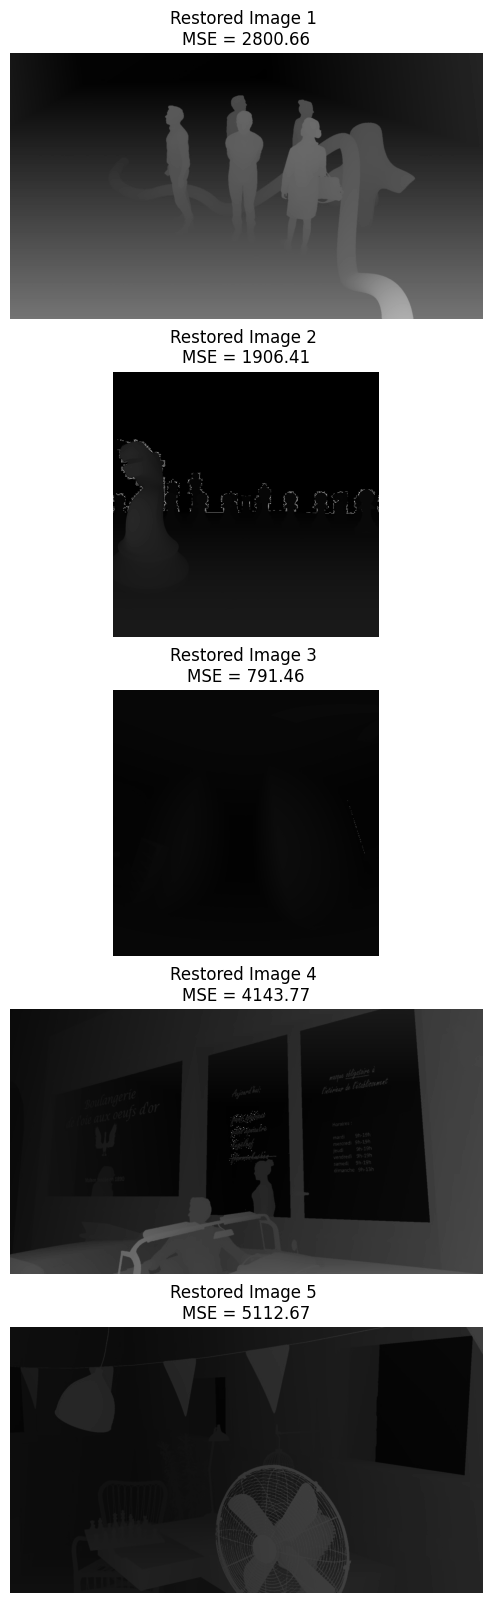

In [2]:
#방법2 코드

def map_to_rgb(value):
    if 0 <= value < 256:
        return (255, value, 0)                    #(255, 0~255, 0)
    elif 256 <= value < 512:
        return (255 - (value - 256), 255, 0)      #(255~0, 255, 0)
    elif 512 <= value < 768:
        return (0, 255, value - 512)              #(0, 255, 0~255)
    elif 768 <= value < 1024:
        return (0, 255 - (value - 768), 255)      #(0, 255~0, 255)
    elif 1024 <= value < 1280:
        return (value - 1024, 0, 255)             #(0~255, 0, 255)
    elif 1280 <= value < 1536:
        return (255, 0, 255 - (value - 1280))     #(255, 0, 255~0)

def map_to_value(r, g, b):
    # 기존 조건들
    if r == 255 and 0 <= g < 256 and b == 0:
        return g
    elif 0 <= r < 256 and g == 255 and b == 0:
        return 256 + (255 - r)
    elif r == 0 and g == 255 and 0 <= b < 256:
        return 512 + b
    elif r == 0 and 0 <= g < 256 and b == 255:
        return 768 + (255 - g)
    elif 0 <= r < 256 and g == 0 and b == 255:
        return 1024 + r
    elif r == 255 and g == 0 and 0 <= b < 256:
        return 1280 + (255 - b)
    # 추가된 조건
    else :
        return 0

# 결과 이미지 저장 리스트
results = []

for image_path in image_paths:
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)                     # 원본 이미지 불러오기
    normalized_image = (image / 65535 * 1535).astype(np.uint16)              # 각 픽셀 값 1536으로 줄이기
    rgb_image = np.zeros((*normalized_image.shape, 3), dtype=np.uint8)       # RGB 이미지 저장공간
    restored_image = np.zeros(normalized_image.shape, dtype=np.uint16)       # 복원 이미지 저장공간

    #원본에서 RGB로 변환
    for i in range(normalized_image.shape[0]):
        for j in range(normalized_image.shape[1]):
            rgb_image[i, j] = map_to_rgb(normalized_image[i, j])

    #Gaussian 노이즈 추가
    noise = np.random.normal(0, 50, rgb_image.shape).astype(np.int16)        # 표준편차 설정
    noisy_rgb_image = np.clip(rgb_image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    #JPEG 압축
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 30]                       # QP 설정
    _, compressed_img = cv2.imencode('.jpg', rgb_image, encode_param)        # JPEG로 압축
    decoded_img = cv2.imdecode(compressed_img, cv2.IMREAD_UNCHANGED)         # 다시 복원

    #RGB 이미지를 다시 원본 16비트 값으로 복원
    for i in range(decoded_img.shape[0]):
        for j in range(decoded_img.shape[1]):
            r, g, b = decoded_img[i, j]
            restored_image[i, j] = map_to_value(r, g, b)

    restored_image = (restored_image / 1535 * 65535).astype(np.uint16)       # 복원 이미지 16비트로 설정
    mse_value = calculate_mse(image, restored_image)                         # MSE 계산
    results.append((restored_image, mse_value))                              # 리스트에 원본, 복원된 이미지 저장

# 시각화
plt.figure(figsize=(10, 20))

for idx, (restored, mse) in enumerate(results):

    plt.subplot(len(results), 1, idx + 1)
    plt.title(f'Restored Image {idx + 1} \nMSE = {mse:.2f}')
    plt.imshow(restored, cmap='gray', vmin=0, vmax=65535)
    plt.axis('off')

plt.show()

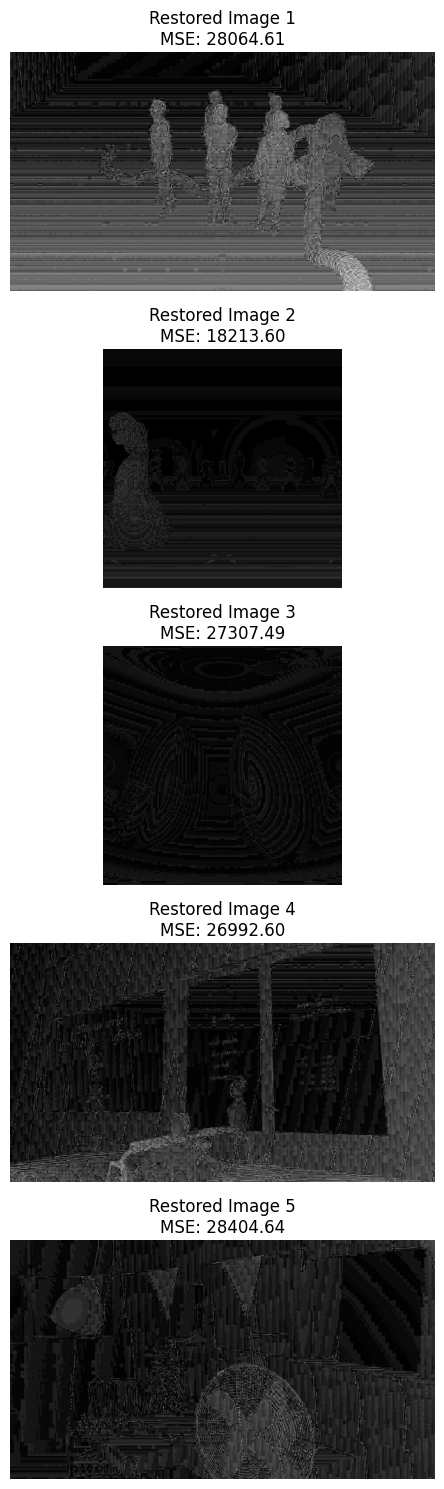

In [ ]:
#방법3 코드

#RGB로 변환 함수
def map_16bit_to_rgb(image_16bit):
    height, width = image_16bit.shape
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)     #RGB 이미지 저장공간

    for i in range(height):
        for j in range(width):
            pixel_value = image_16bit[i, j]

            r_ch = (pixel_value >> 10) & 0x3F                    #상위 6비트
            g_ch = (pixel_value >> 4) & 0x3F                     #중간 6비트
            b_ch = pixel_value & 0x0F                            #하위 4비트

            rgb_image[i, j, 0] = r_ch                            #R 채널
            rgb_image[i, j, 1] = g_ch                            #G 채널
            rgb_image[i, j, 2] = b_ch                            #B 채널

    return rgb_image

#RGB 이미지를 16비트로 다시 복원하는 함수
def map_rgb_to_16bit(rgb_image):
    height, width, _ = rgb_image.shape
    restored_image = np.zeros((height, width), dtype=np.uint16)  #복원 이미지 저장공간

#RGB 값을 다시 16비트 값으로 결합
    for i in range(height):
        for j in range(width):
            r_ch = rgb_image[i, j, 0]
            g_ch = rgb_image[i, j, 1]
            b_ch = rgb_image[i, j, 2]

            restored_image[i, j] = (r_ch << 10) | (g_ch << 4) | b_ch

    return restored_image

#결과 저장 리스트
results = []

for image_path in image_paths:
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    rgb_image = map_16bit_to_rgb(image)

    noise = np.random.normal(0, 50, rgb_image.shape).astype(np.int16)
    noisy_rgb_image = np.clip(rgb_image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 30]
    _, compressed_img = cv2.imencode('.jpg', rgb_image, encode_param)
    decoded_img = cv2.imdecode(compressed_img, cv2.IMREAD_UNCHANGED)

    #노이즈 종류 선택하기
    restored_image = map_rgb_to_16bit(decoded_img)
    mse_value = calculate_mse(image, restored_image)

    results.append((restored_image, mse_value))

# 시각화
plt.figure(figsize=(10,15))

for idx, (restored, mse) in enumerate(results):

    plt.subplot(len(results), 1, idx + 1)
    plt.title(f'Restored Image {idx + 1}\nMSE: {mse:.2f}')
    plt.imshow(restored, cmap='gray', vmin=0, vmax=65535)
    plt.axis('off')

plt.show()